In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
medical=pd.read_csv('C:\\Users\\hp\\Downloads\\insurance.csv')
medical.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
medical.shape

(1338, 7)

In [3]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
medical.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
def plot_hist(df:pd.DataFrame,col:str):
    plt.figure()
    df[col].hist(bins=20)
    plt.title(f'distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

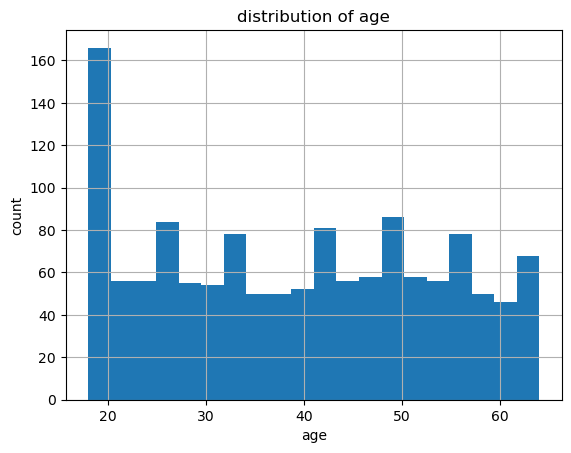

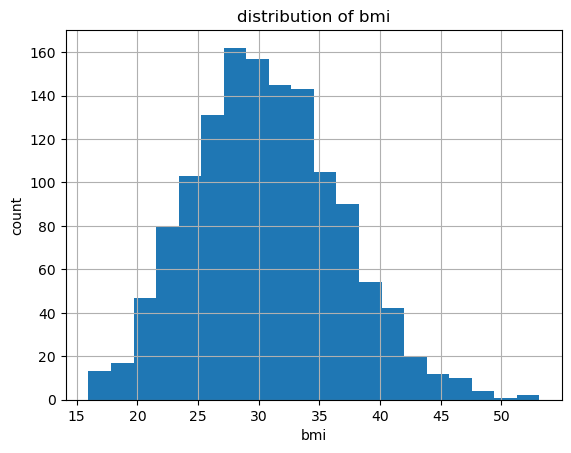

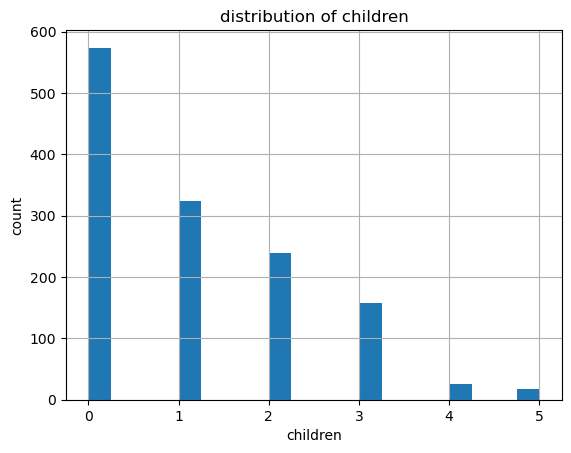

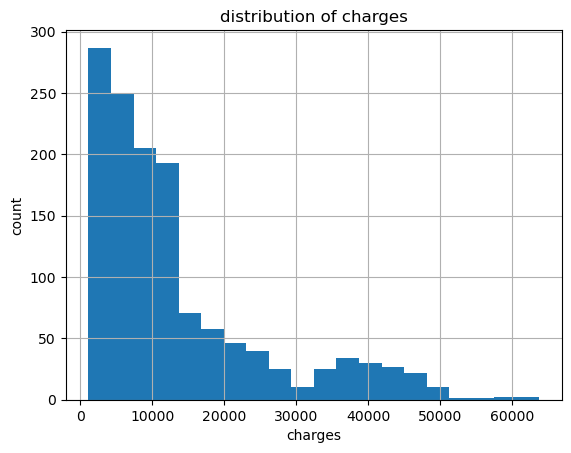

In [6]:
for col in ['age','bmi','children','charges']:
    plot_hist(medical,col)

In [7]:
def plot_cat(df: pd.DataFrame,col:str):
    plt.figure()
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'counts by {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

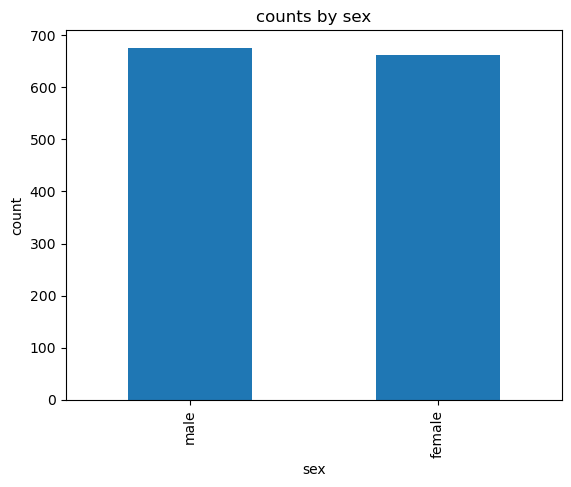

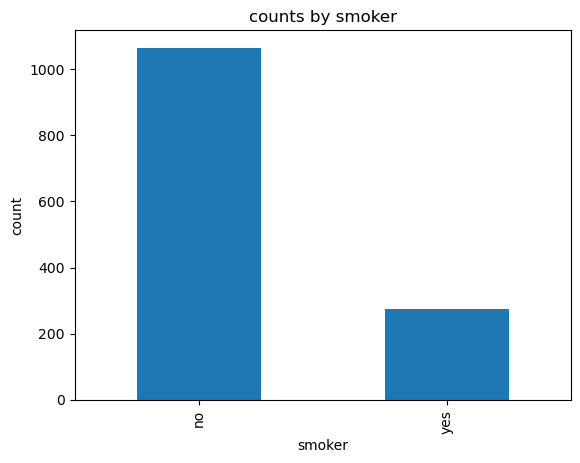

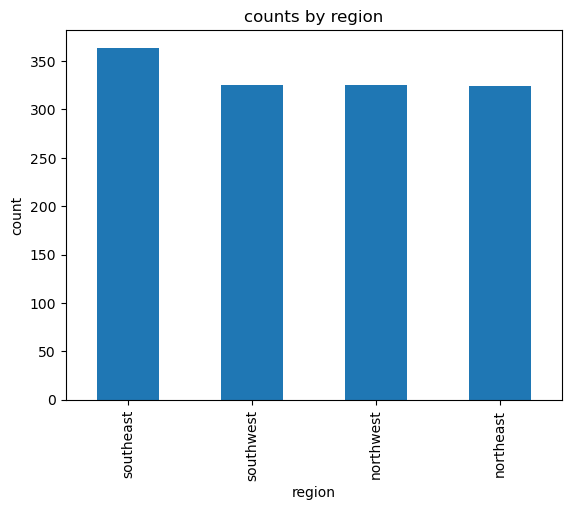

In [8]:
for col in ['sex','smoker','region']:
    plot_cat(medical,col)

In [9]:
def plot_scatter(df: pd.DataFrame, xcol: str, ycol: str):
    plt.figure()
    plt.scatter(df[xcol], df[ycol])
    plt.title(f"{xcol} vs {ycol}")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.tight_layout()
    plt.show()

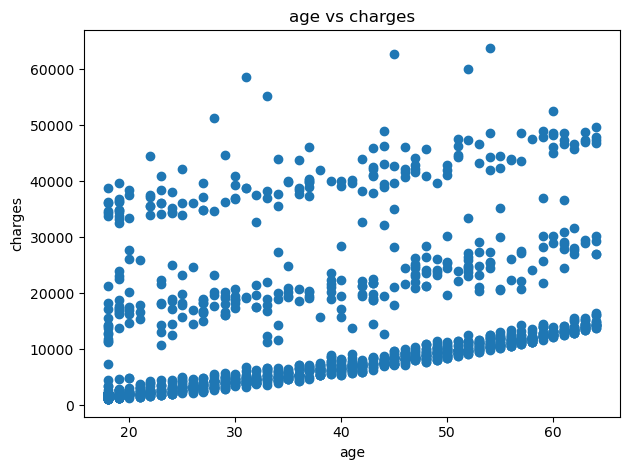

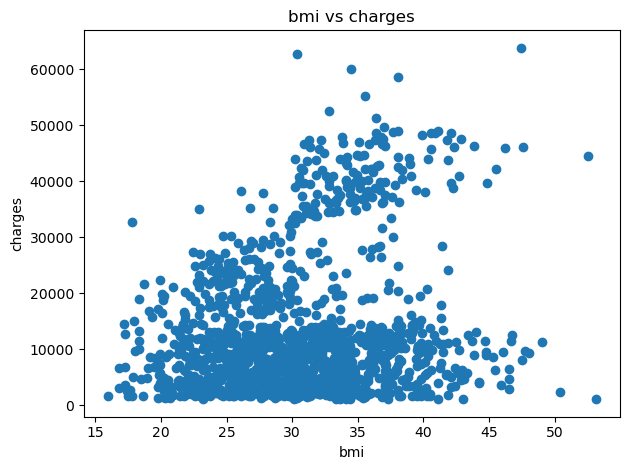

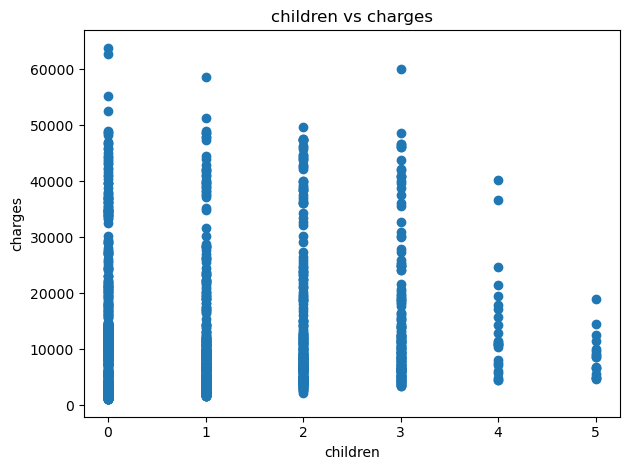

In [11]:
for x in ["age", "bmi", "children"]:
    plot_scatter(medical, x, "charges")

In [12]:
def plot_box_by_group(df: pd.DataFrame, value_col: str, group_col: str):
    plt.figure()
    groups = df.groupby(group_col)[value_col].apply(list)
    positions = range(1, len(groups) + 1)
    plt.boxplot(groups.tolist(), positions=list(positions), labels=list(groups.index))
    plt.title(f"{value_col} by {group_col}")
    plt.xlabel(group_col)
    plt.ylabel(value_col)
    plt.tight_layout()
    plt.show()

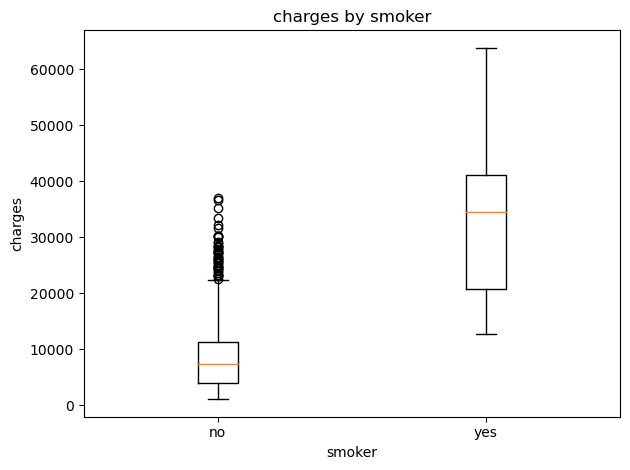

In [14]:
plot_box_by_group(medical, "charges", "smoker")

In [15]:
def plot_corr_heatmap(df: pd.DataFrame, numeric_cols: list[str]):
    corr = df[numeric_cols].corr()
    plt.figure()
    plt.imshow(corr, interpolation='nearest')
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
    plt.yticks(range(len(numeric_cols)), numeric_cols)
    plt.title("Correlation heatmap (numeric)")
    for (i, j) in itertools.product(range(len(numeric_cols)), range(len(numeric_cols))):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

NameError: name 'itertools' is not defined

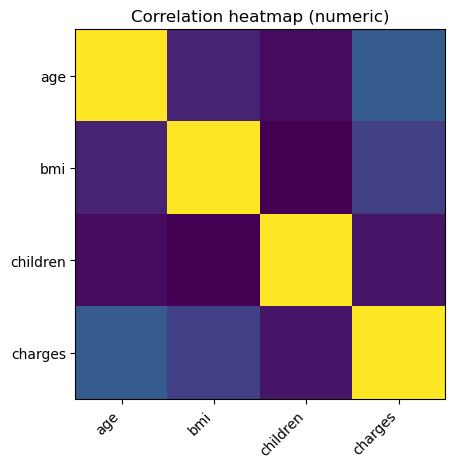

In [19]:
plot_corr_heatmap(medical, ["age", "bmi", "children", "charges"])